In [33]:
import pandas, seaborn

import scipy, scipy.stats
import matplotlib, matplotlib.pyplot


In [15]:
# user-defined variables
input_file = '/Users/adrian/research/bmcbf/029_orsay/results/006.DDBs/DDBs_WT.for.tsv'
expression_file = '/Users/adrian/research/bmcbf/029_orsay/results/000.quantification/results/DESeq2_TPM_values.tsv'

In [17]:
# read info
expression = pandas.read_csv(expression_file, sep='\t', index_col=0)

In [18]:
expression.index = expression.index.str.split('.').str[0]

print(expression.shape)
expression.drop(['P9T001', 'P9T004', 'P9T009'], axis=1, inplace=True)
print(expression.shape)

(34183, 34)
(34183, 31)


In [19]:
df = pandas.read_csv(input_file, sep='\t')
sub = df[df['log2FoldChange'] < 0]
sub.sort_values(by='log2FoldChange')

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,ensembl_id,gene_name,biotype,description2,medianTPM_WT,medianTPM_all
ENSMUSG00000032368,376.873173,-1.874631,0.962822,17.742873,4.969539e-04,1.721198e-02,ENSMUSG00000032368,Zic1,protein_coding,zinc finger protein of the cerebellum 1,8.967311,1.586966
ENSMUSG00000050010,202.393195,-1.429376,0.654878,16.295925,9.860697e-04,2.792698e-02,ENSMUSG00000050010,Shisa3,protein_coding,shisa family member 3,4.462898,1.276265
ENSMUSG00000091345,1555.842346,-1.350666,0.443568,23.399662,3.333244e-05,2.631865e-03,ENSMUSG00000091345,Col6a5,protein_coding,"collagen, type VI, alpha 5",15.778656,6.669400
ENSMUSG00000115420,624.053616,-1.335998,0.627925,18.922781,2.836360e-04,1.208503e-02,ENSMUSG00000115420,Rmrp,lncRNA,RNA component of mitochondrial RNAase P,226.258293,131.362211
ENSMUSG00000053113,2809.991359,-1.302679,0.340268,22.944861,4.146592e-05,3.060076e-03,ENSMUSG00000053113,Socs3,protein_coding,suppressor of cytokine signaling 3,66.630113,36.702212
ENSMUSG00000099587,27.123729,-1.300340,0.572160,17.952736,4.498332e-04,1.655896e-02,ENSMUSG00000099587,Gm28967,lncRNA,predicted gene 28967,10.806842,4.687333
ENSMUSG00000071470,186.280205,-1.260119,0.637560,20.414755,1.392509e-04,7.307506e-03,ENSMUSG00000071470,Ccnb1ip1,protein_coding,cyclin B1 interacting protein 1,35.637525,18.294589
ENSMUSG00000056296,298.596546,-1.237899,0.612141,20.842351,1.135180e-04,6.419720e-03,ENSMUSG00000056296,Synpr,protein_coding,synaptoporin,9.900848,2.845842
ENSMUSG00000036972,72.369831,-1.220968,0.942822,14.377115,2.434288e-03,4.783390e-02,ENSMUSG00000036972,Zic4,protein_coding,zinc finger protein of the cerebellum 4,2.304643,0.725539
ENSMUSG00000033308,242.236554,-1.212714,0.361202,62.993020,1.347606e-13,5.071941e-10,ENSMUSG00000033308,Dpyd,protein_coding,dihydropyrimidine dehydrogenase,3.381074,1.454030


In [21]:
biomarkers = list(sub.index)

In [22]:
df = expression.loc[biomarkers]
df

,P9T002,P9T003,P9T005,P9T006,P9T007,P9T008,P9T010,P9T011,P9T012,P9T013,...,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T033,P9T034
ENSMUSG00000033308,2.776304,6.390751,3.692633,3.069515,3.061683,4.571894,4.363611,2.046569,5.018204,2.476518,...,1.454030,1.355515,0.703188,0.564670,0.879528,0.596846,1.075373,2.200291,1.367883,2.090487
ENSMUSG00000034394,21.876112,13.571332,42.489780,16.099713,40.681755,14.187001,9.246905,9.334773,10.918618,10.214580,...,7.910788,8.530758,10.094681,14.476410,13.285303,15.558664,6.301973,8.062981,22.638860,9.669246
ENSMUSG00000030124,13.411665,15.231313,22.740764,11.791541,19.025335,8.828053,8.474153,4.727594,8.229261,9.232248,...,4.903183,8.401615,4.620849,3.922125,11.301971,8.231642,6.179308,7.541917,8.124075,6.226719
ENSMUSG00000091345,12.752633,16.185681,22.151639,15.798343,13.366980,15.758969,17.921589,11.860076,7.305931,16.673996,...,8.056274,7.063107,5.389560,1.785718,3.896339,6.669400,5.848290,6.022670,5.013879,8.079696
ENSMUSG00000053113,77.887836,31.648329,64.684497,63.442577,138.642064,68.575729,36.702212,38.242508,29.300221,53.923871,...,24.729609,93.494760,28.661425,39.056400,59.723115,52.153258,19.234404,24.606782,45.201567,29.082527
ENSMUSG00000047793,75.014778,60.611566,74.208753,50.988156,101.309670,67.484448,74.652277,44.375087,28.285843,52.198878,...,32.762619,29.542565,35.780586,28.291711,47.636323,73.653916,28.005827,29.169629,40.239508,31.669774
ENSMUSG00000056296,10.273691,9.252404,21.879741,5.648290,14.839441,9.528005,4.932094,6.634528,2.358134,2.097811,...,1.358118,1.124795,0.925208,4.368532,14.303296,2.339608,1.492699,4.308653,6.836111,7.232813
ENSMUSG00000071470,26.479700,44.795350,73.777315,48.616749,22.357022,18.600153,42.517183,18.294589,77.983974,74.434153,...,22.747925,11.963078,29.511705,5.713285,4.629091,2.980530,3.277309,12.652190,22.128487,26.986869
ENSMUSG00000115420,169.548834,267.648604,552.965203,384.887597,184.867981,141.029760,327.275850,175.597946,478.899612,526.281004,...,198.018324,78.512248,259.940361,26.414832,28.120184,32.458262,28.144726,91.995831,131.362211,194.977162
ENSMUSG00000099587,10.258417,11.167035,21.412375,14.549016,8.709586,10.446649,10.307901,4.434029,21.893261,16.494910,...,12.037588,3.650587,8.872004,1.347955,1.704254,1.808248,3.717589,5.479376,4.687333,6.480327


In [25]:
df_zscore = df.apply(scipy.stats.zscore, axis=1)
df_zscore

,P9T002,P9T003,P9T005,P9T006,P9T007,P9T008,P9T010,P9T011,P9T012,P9T013,...,P9T025,P9T026,P9T027,P9T028,P9T029,P9T030,P9T031,P9T032,P9T033,P9T034
ENSMUSG00000033308,0.401516,2.947021,1.046849,0.608012,0.602496,1.666075,1.519390,-0.112406,1.980393,0.190389,...,-0.529707,-0.599087,-1.058493,-1.156046,-0.934304,-1.133385,-0.796379,-0.004146,-0.590376,-0.081477
ENSMUSG00000034394,0.992191,0.024047,3.395264,0.318797,3.184491,0.095820,-0.480080,-0.469837,-0.285198,-0.367272,...,-0.635841,-0.563567,-0.381250,0.129558,-0.009297,0.255724,-0.823391,-0.618098,1.081109,-0.430845
ENSMUSG00000030124,1.134434,1.556919,3.300463,0.758273,2.437815,0.070211,-0.011958,-0.881833,-0.068816,0.164057,...,-0.841065,-0.028799,-0.906617,-1.068847,0.644605,-0.068264,-0.544774,-0.228404,-0.093239,-0.533767
ENSMUSG00000091345,0.570942,1.195851,2.281821,1.125345,0.682770,1.118178,1.511835,0.408471,-0.420509,1.284738,...,-0.283926,-0.464710,-0.769342,-1.425341,-1.041150,-0.536376,-0.685841,-0.654098,-0.837726,-0.279663
ENSMUSG00000053113,1.321832,-0.569327,0.781826,0.731033,3.806632,0.940975,-0.362627,-0.299630,-0.665362,0.341725,...,-0.852297,1.960143,-0.691489,-0.266342,0.578910,0.269309,-1.077046,-0.857320,-0.015010,-0.674266
ENSMUSG00000047793,1.290456,0.578239,1.250600,0.102375,2.590700,0.918093,1.272531,-0.224631,-1.020220,0.162244,...,-0.798851,-0.958077,-0.649617,-1.019930,-0.063368,1.223164,-1.034067,-0.976519,-0.429129,-0.852890
ENSMUSG00000056296,0.937350,0.726960,3.328250,-0.015504,1.877916,0.783736,-0.163043,0.187666,-0.693291,-0.746919,...,-0.899299,-0.947364,-0.988480,-0.279140,1.767468,-0.697107,-0.871575,-0.291475,0.229193,0.310916
ENSMUSG00000071470,0.055766,0.939310,2.337395,1.123653,-0.143112,-0.324342,0.829411,-0.339083,2.540324,2.369081,...,-0.124255,-0.644514,0.202029,-0.946003,-0.998304,-1.077831,-1.063514,-0.611271,-0.154136,0.080231
ENSMUSG00000115420,-0.118468,0.553142,2.506478,1.355784,-0.013590,-0.313716,0.961363,-0.077055,1.999410,2.323792,...,0.076440,-0.741723,0.500370,-1.098393,-1.086718,-1.057018,-1.086550,-0.649412,-0.379902,0.055619
ENSMUSG00000099587,0.383741,0.546219,2.378274,1.150979,0.106782,0.417401,0.392590,-0.657766,2.464265,1.498941,...,0.701890,-0.797860,0.135825,-1.209613,-1.145900,-1.127304,-0.785879,-0.470839,-0.612471,-0.291851


In [29]:
group_dict = {}

# Group A: P9T002 to P9T008 (excluding P9T004 and P9T009)
for i in range(1, 10):
    if i not in [1, 4, 9]:
        sample_id = f"P9T{i:03d}"
        group_dict[sample_id] = "WT"

# Group B: P9T010 to P9T015
for i in range(10, 19):
    sample_id = f"P9T{i:03d}"
    group_dict[sample_id] = "HET"

# Group C: P9T020 to P9T025
for i in range(19, 31):
    sample_id = f"P9T{i:03d}"
    group_dict[sample_id] = "HOM"

for i in range(31, 35):
    sample_id = f"P9T{i:03d}"
    group_dict[sample_id] = "VGA"

# # (Optional) Preview
# for element in group_dict:
#     print(element, group_dict[element])

group_series = pandas.Series(group_dict).reindex(df_zscore.columns)
group_colors = group_series.map({'WT': 'gray', 'HET': 'gold', 'HOM': 'tab:red', 'VGA': 'skyblue'})

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

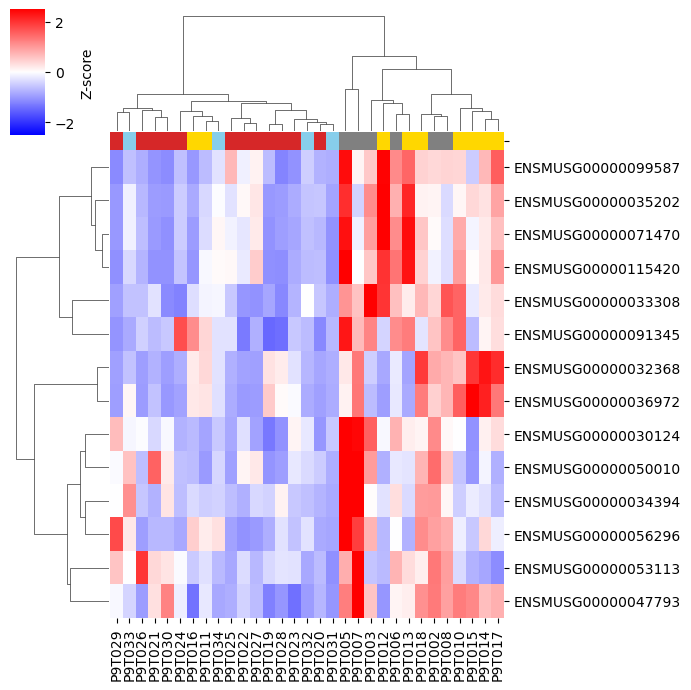

In [36]:
g = seaborn.clustermap(
    df_zscore,
    metric='euclidean',     # distance metric
    method='ward',       # clustering method (e.g., single, complete, average, ward)
    cmap='bwr',            # color map (others: 'coolwarm', 'viridis', 'mako', 'rocket')
    standard_scale=None,    # or 0 (rows) or 1 (columns) if you didn't z-score earlier
    figsize=(7, 7),
    col_colors=group_colors,
    #row_colors=row_colors,
    dendrogram_ratio=(0.2, 0.2),  # adjust size of dendrograms
    cbar_pos=(0.02, 0.8, 0.05, 0.18),  # colorbar position
    xticklabels=True,
    cbar_kws={'label': 'Z-score'},
    vmin=-2.5,
    vmax=2.5,
    yticklabels=True
)
matplotlib.pyplot.setp(g.ax_heatmap.get_yticklabels(), rotation=0)